In [49]:
!uv pip install pandas numpy matplotlib seaborn scikit-learn

Using Python 3.13.13 environment at: /home/lesaloon/Work/2026_ESIEA_S8_DATA_VISUALISATION/.venv
Checked 5 packages in 1ms


In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

In [51]:
df_listings = pd.read_csv('listing.csv.gz')

In [52]:
df_listings.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,114543,https://www.airbnb.com/rooms/114543,20260616211535,2026-06-21,city scrape,Charming 55m² flat - Eiffel Tower,Fully furnished charming flat with lots of spa...,NaN,https://a0.muscache.com/pictures/airflow/Hosti...,581233,...,4.97,4.93,4.77,7511502831082,NaN,1,1,0,0,0.83
1,115107,https://www.airbnb.com/rooms/115107,20260616211535,2026-06-25,previous scrape,Charming two-bed apartment with balcony,This charming 60 square meter apartment is per...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,379042,...,5.00,4.40,4.40,7511002008206,NaN,2,1,1,0,0.22
2,115655,https://www.airbnb.com/rooms/115655,20260616211535,2026-06-20,city scrape,Family loft with a private courtyard,"Beautiful openplan loft situated in a private,...",NaN,https://a0.muscache.com/pictures/33160696/6171...,584977,...,4.69,4.04,4.40,7511805457226,NaN,1,1,0,0,1.24
3,120494,https://www.airbnb.com/rooms/120494,20260616211535,2026-06-19,city scrape,Romantic Hideout in Paris,"""As full of spirit as the month of May, as gor...",NaN,https://a0.muscache.com/pictures/833324/f66a6b...,606427,...,4.97,4.85,4.75,7511300905786,NaN,1,1,0,0,2.03
4,125686,https://www.airbnb.com/rooms/125686,20260616211535,2026-06-20,city scrape,Studio - République/Canal Saint Martin,"Tiny studio in central Paris, between the Mara...",NaN,https://a0.muscache.com/pictures/2704337/e28df...,624523,...,4.92,4.87,4.69,"Available with a mobility lease only (""bail mo...",NaN,1,1,0,0,0.79


In [53]:
df_listings['price'] = (
    df_listings['price']
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .pipe(pd.to_numeric, errors='coerce')
)

In [54]:
df_listings.info()

<class 'pandas.DataFrame'>
RangeIndex: 77679 entries, 0 to 77678
Data columns (total 90 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            77679 non-null  int64  
 1   listing_url                                   77679 non-null  str    
 2   scrape_id                                     77679 non-null  int64  
 3   last_scraped                                  77679 non-null  str    
 4   source                                        77679 non-null  str    
 5   name                                          77679 non-null  str    
 6   description                                   74850 non-null  str    
 7   neighborhood_overview                         0 non-null      float64
 8   picture_url                                   77678 non-null  str    
 9   host_id                                       77679 non-null  int64  
 1

In [55]:
neighborhood_list = df_listings['neighbourhood_cleansed'].unique()
print(neighborhood_list)

<StringArray>
[          'Vaugirard',   'Buttes-Montmartre',            'Gobelins',
            'Entrepôt',               'Opéra',          'Popincourt',
        'Observatoire',      'Hôtel-de-Ville',              'Bourse',
 'Batignolles-Monceau',               'Passy',     'Buttes-Chaumont',
          'Luxembourg',              'Louvre',             'Reuilly',
              'Élysée',            'Panthéon',        'Ménilmontant',
              'Temple',      'Palais-Bourbon']
Length: 20, dtype: str


In [56]:

df_listings['review_scores_rating'] = pd.to_numeric(
    df_listings['review_scores_rating'],
    errors='coerce'
)
df_listings['price_per_score'] = df_listings['price'] / df_listings['review_scores_rating']

neighborhood_overview = (
    df_listings.groupby('neighbourhood_cleansed')
    .agg({
        'id': 'count',
        'price': 'mean',
        'review_scores_rating': 'mean',
        'price_per_score': 'mean'
    })
    .reset_index()
)


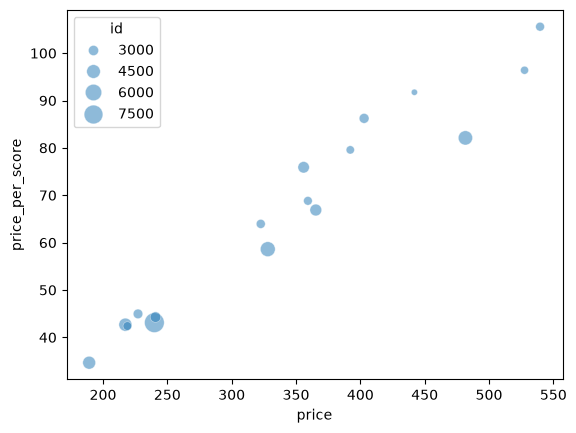

In [57]:
plot = sns.scatterplot(
    data=neighborhood_overview,
    x='price',
    y='price_per_score',
    size='id',
    sizes=(20, 200),
    alpha=0.5
)

In [58]:
neighborhood_overview.sort_values('price_per_score', ascending=False)

,neighbourhood_cleansed,id,price,review_scores_rating,price_per_score
15,Popincourt,6899,245.774612,4.768487,inf
18,Vaugirard,6224,275.834755,4.740989,inf
4,Entrepôt,5330,263.376212,4.752439,inf
19,Élysée,2569,539.669695,4.717645,105.584063
12,Palais-Bourbon,2320,527.594754,4.728839,96.388777
7,Louvre,1862,441.998109,4.741942,91.744787
1,Bourse,2894,402.913117,4.695191,86.228790
14,Passy,4817,481.648860,4.743550,82.109325
8,Luxembourg,2400,392.169015,4.722419,79.578275
17,Temple,3511,355.909087,4.724777,75.904145


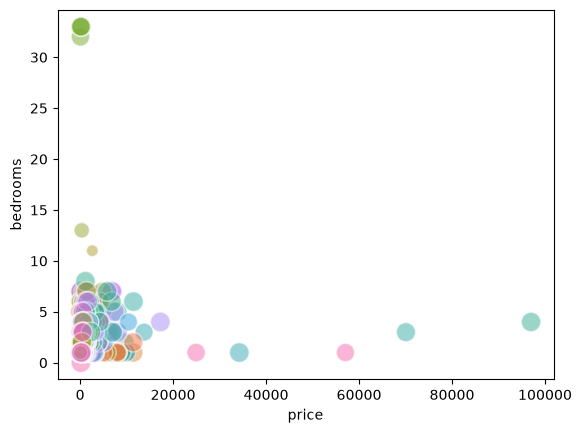

In [59]:
# plot price per number of room per neighborhood
plot = sns.scatterplot(
    data=df_listings,
    x='price',
    y='bedrooms',
    hue='neighbourhood_cleansed',
    size='review_scores_rating',
    alpha=0.5,
    legend=False,
    sizes=(40, 200)
)

In [60]:
df_foncier = pd.read_csv('ValeursFoncieres-2025.txt', sep='|')

/tmp/ipykernel_185685/3953252857.py:1: DtypeWarning: Columns (0: Code departement, 1: No Volume, 2: 1er lot, 3: 2eme lot, 4: 3eme lot, 5: Surface Carrez du 3eme lot, 6: Surface Carrez du 4eme lot, 7: Surface Carrez du 5eme lot, 8: Nature culture speciale) have mixed types. Specify dtype option on import or set low_memory=False.
  df_foncier = pd.read_csv('ValeursFoncieres-2025.txt', sep='|')


In [61]:
df_foncier.info()

<class 'pandas.DataFrame'>
RangeIndex: 3714829 entries, 0 to 3714828
Data columns (total 43 columns):
 #   Column                      Dtype  
---  ------                      -----  
 0   Identifiant de document     float64
 1   Reference document          float64
 2   1 Articles CGI              float64
 3   2 Articles CGI              float64
 4   3 Articles CGI              float64
 5   4 Articles CGI              float64
 6   5 Articles CGI              float64
 7   No disposition              int64  
 8   Date mutation               str    
 9   Nature mutation             str    
 10  Valeur fonciere             str    
 11  No voie                     float64
 12  B/T/Q                       str    
 13  Type de voie                str    
 14  Code voie                   str    
 15  Voie                        str    
 16  Code postal                 float64
 17  Commune                     str    
 18  Code departement            object 
 19  Code commune                int6

In [62]:
print(df_foncier['Commune'].unique())

<StringArray>
[             'FARGES',           'MONTANGES',             'BUELLAS',
                 'GEX',             'BANEINS',     'FERNEY-VOLTAIRE',
 'AMBERIEUX-EN-DOMBES',       'PONT-DE-VEYLE',               'RANCE',
              'THOIRY',
 ...
            'PARIS 01',            'PARIS 05',            'PARIS 15',
            'PARIS 06',            'PARIS 12',            'PARIS 14',
            'PARIS 16',            'PARIS 11',            'PARIS 13',
            'PARIS 07']
Length: 30776, dtype: str


In [63]:
# 16  Code postal                 float64
df_foncier_paris = df_foncier[df_foncier['Commune'].str.contains('PARIS')]

In [64]:
print(df_foncier_paris.size)

3785935


In [65]:
df_foncier_paris.info()

<class 'pandas.DataFrame'>
Index: 88045 entries, 1436300 to 3714828
Data columns (total 43 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Identifiant de document     0 non-null      float64
 1   Reference document          0 non-null      float64
 2   1 Articles CGI              0 non-null      float64
 3   2 Articles CGI              0 non-null      float64
 4   3 Articles CGI              0 non-null      float64
 5   4 Articles CGI              0 non-null      float64
 6   5 Articles CGI              0 non-null      float64
 7   No disposition              88045 non-null  int64  
 8   Date mutation               88045 non-null  str    
 9   Nature mutation             88045 non-null  str    
 10  Valeur fonciere             86991 non-null  str    
 11  No voie                     87223 non-null  float64
 12  B/T/Q                       3700 non-null   str    
 13  Type de voie                87401 non-n

In [ ]:
#  #   Column                      Non-Null Count  Dtype  
# ---  ------                      --------------  -----  
#  0   Identifiant de document     0 non-null      float64
#  1   Reference document          0 non-null      float64
#  2   1 Articles CGI              0 non-null      float64
#  3   2 Articles CGI              0 non-null      float64
#  4   3 Articles CGI              0 non-null      float64
#  5   4 Articles CGI              0 non-null      float64
#  6   5 Articles CGI              0 non-null      float64
#  7   No disposition              88045 non-null  int64  
#  8   Date mutation               88045 non-null  str    
#  9   Nature mutation             88045 non-null  str    
#  10  Valeur fonciere             86991 non-null  str    
#  11  No voie                     87223 non-null  float64
#  12  B/T/Q                       3700 non-null   str    
#  13  Type de voie                87401 non-null  str    
#  14  Code voie                   87848 non-null  str    
#  15  Voie                        87848 non-null  str    
#  16  Code postal                 87848 non-null  float64
#  17  Commune                     88045 non-null  str    
#  18  Code departement            88045 non-null  object 
#  19  Code commune                88045 non-null  int64  
#  20  Prefixe de section          0 non-null      float64
#  21  Section                     88045 non-null  str    
#  22  No plan                     88045 non-null  int64  
#  23  No Volume                   238 non-null    object 
#  24  1er lot                     77378 non-null  object 
#  25  Surface Carrez du 1er lot   31812 non-null  str    
#  26  2eme lot                    35336 non-null  object 
#  27  Surface Carrez du 2eme lot  9406 non-null   str    
#  28  3eme lot                    5905 non-null   object 
#  29  Surface Carrez du 3eme lot  953 non-null    str    
#  30  4eme lot                    2180 non-null   float64
#  31  Surface Carrez du 4eme lot  230 non-null    str    
#  32  5eme lot                    952 non-null    float64
#  33  Surface Carrez du 5eme lot  106 non-null    str    
#  34  Nombre de lots              88045 non-null  int64  
#  35  Code type local             86704 non-null  float64
#  36  Type local                  86704 non-null  str    
#  37  Identifiant local           0 non-null      float64
#  38  Surface reelle bati         86695 non-null  float64
#  39  Nombre pieces principales   86695 non-null  float64
#  40  Nature culture              10433 non-null  str    
#  41  Nature culture speciale     149 non-null    str    
#  42  Surface terrain             10433 non-null  float64

def clean_foncier_data(df):
    # Convert 'Valeur fonciere' to numeric, coercing errors to NaN
    df['Valeur fonciere'] = pd.to_numeric(df['Valeur fonciere'], errors='coerce')
    
    # Convert 'Date mutation' to datetime
    df['Date mutation'] = pd.to_datetime(df['Date mutation'], errors='coerce')
    
    # Drop rows with NaN in critical columns
    df = df.dropna(subset=['Valeur fonciere', 'Date mutation', 'Commune'])
    
    return df

def filter_paris_data(df):
    # Filter for rows where 'Commune' contains 'PARIS'
    df_paris = df[df['Commune'].str.contains('PARIS', na=False)]
    return df_paris

def clean_foncier_types(df):
    """
        for each field we are forcing the right data type, and if the conversion fails we will set the value to NaN
    """
    # Identifiant de document 
    df['Identifiant de document'] = pd.to_numeric(df['Identifiant de document'], errors='coerce')
    # Reference document
    df['Reference document'] = pd.to_numeric(df['Reference document'], errors='coerce')
    # 1 Articles CGI
    df['1 Articles CGI'] = pd.to_numeric(df['1 Articles CGI'], errors='coerce')
    # 2 Articles CGI
    df['2 Articles CGI'] = pd.to_numeric(df['2 Articles CGI'], errors='coerce')
    # 3 Articles CGI
    df['3 Articles CGI'] = pd.to_numeric(df['3 Articles CGI'], errors='coerce')
    # 4 Articles CGI
    df['4 Articles CGI'] = pd.to_numeric(df['4 Articles CGI'], errors='coerce')
    # 5 Articles CGI
    df['5 Articles CGI'] = pd.to_numeric(df['5 Articles CGI'], errors='coerce')
    # No disposition
    df['No disposition'] = pd.to_numeric(df['No disposition'], errors='coerce')
    # Valeur fonciere
    df['Valeur fonciere'] = pd.to_numeric(df['Valeur fonciere'], errors='coerce')
    # No voie
    df['No voie'] = pd.to_numeric(df['No voie'], errors='coerce')
    # Code postal
    df['Code postal'] = pd.to_numeric(df['Code postal'], errors='coerce')
    # Code commune
    df['Code commune'] = pd.to_numeric(df['Code commune'], errors='coerce')
    # No plan
    df['No plan'] = pd.to_numeric(df['No plan'], errors='coerce')
    # Surface Carrez du 1er lot
    df['Surface Carrez du 1er lot'] = pd.to_numeric(df['Surface Carrez du 1er lot'], errors='coerce')
    # Surface Carrez du 2eme lot
    df['Surface Carrez du 2eme lot'] = pd.to_numeric(df['Surface Carrez du 2eme lot'], errors='coerce')
    # Surface Carrez du 3eme lot
    df['Surface Carrez du 3eme lot'] = pd.to_numeric(df['Surface Carrez du 3eme lot'], errors='coerce')
    # Surface Carrez du 4eme lot
    df['Surface Carrez du 4eme lot'] = pd.to_numeric(df['Surface Carrez du 4eme lot'], errors='coerce')
    
    return df